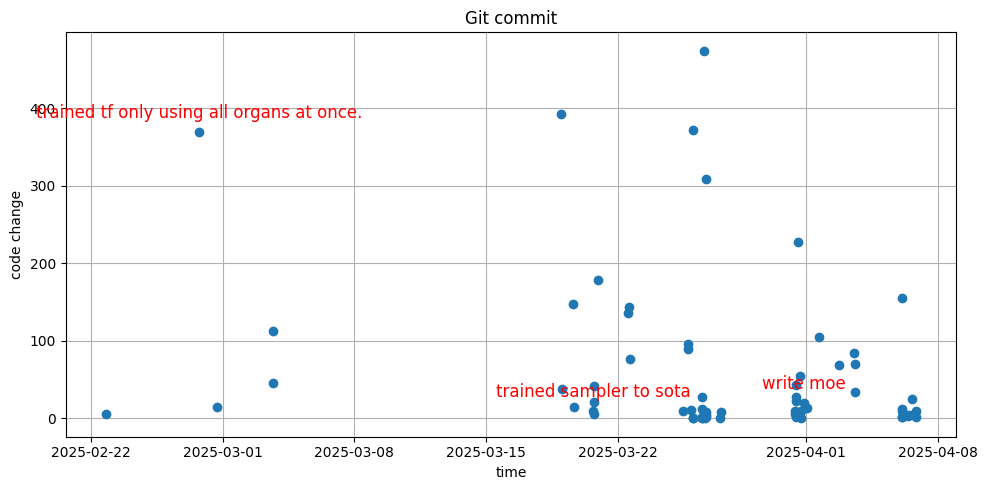

In [24]:
import matplotlib.pyplot as plt
from datetime import datetime

# 读取提交数据
with open('commits.txt', 'r') as file:
    lines = file.readlines()

# 解析数据
dates = []
changes = []
messages = []

i = 0
while i < len(lines):
    line = lines[i].strip()
    if line.startswith((' ', '\t')) or not line:
        i += 1
        continue
    
    parts = line.split()
    if len(parts) >= 3:
        # 提取提交信息
        commit_hash = parts[0]
        
        try:
            # 尝试解析日期
            date_str = parts[1] + ' ' + parts[2]
            date = datetime.fromisoformat(date_str)
            
            # 过滤2025年及之后的记录
            if date >= datetime(2025,2,22):
                dates.append(date)
                message = ' '.join(parts[3:])
                messages.append(message)
                
                # 记录修改代码行数
                added, removed = 0, 0
                i += 1
                while i < len(lines) and lines[i].strip() and not lines[i].strip().startswith(commit_hash):
                    change_line = lines[i].strip()
                    change_parts = change_line.split()
                    if len(change_parts) >= 3 and change_parts[0].isdigit() and change_parts[1].isdigit():
                        filename = change_parts[2]
                        # 排除指定文件
                        if '.txt' not in filename and '.ipynb' not in filename:
                            added += int(change_parts[0])
                            removed += int(change_parts[1])
                    i += 1
                
                changes.append(added + removed)
            else:
                i += 1
        except ValueError:
            # 跳过无效日期格式的行
            i += 1
    else:
        i += 1

# 绘制图表
plt.figure(figsize=(10, 5))
plt.plot(dates, changes, marker='o', linestyle='') # 
plt.xlabel('time')
plt.ylabel('code change')
plt.title('Git commit')
selected_commits = [
    'trained sampler to sota',
    'trained tf only using all organs at once.',
    'write moe'
]
# 显示提交信息
for date, change, message in zip(dates, changes, messages):
    message = message.replace('+0800 ', '')
    
    if message not in selected_commits:
        message = ''
    plt.annotate(message, (date, change), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, color='red')

plt.grid(True)
plt.tight_layout()
plt.show()
